# M66 Baseline Simulation and AI Service Optimization

**Project:** Passenger Queue Dynamics and Waiting-Time Simulation for Selected M66 Bus Stops

This notebook builds the baseline discrete-event simulation, runs the required stochastic replications, and compares three AI optimization techniques for hourly M66 service allocation.

The simulation uses the cleaned 2025 MTA Bus Stop-Level Ridership data and the current MTA static GTFS schedule. The AI optimization changes the hourly number and spacing of candidate buses while keeping the simulation rules and passenger streams consistent.

In [1]:
# DATA SOURCES
# MTA Bus Stop Level Ridership: Beginning 2024
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS
# https://www.mta.info/developers
#
# GTFS Schedule Reference
# https://gtfs.org/documentation/schedule/reference/
#
# DEVELOPMENT AND DOCUMENTATION NOTE
# AI-assisted suggestions were used as a starting point for some Python code.
# The group reviewed the simulation rules, adapted the code to the M66 project,
# ran the notebook using the actual project data, checked the outputs, and kept
# the final code that matched the project design.
#
# Official MTA, GTFS, pandas, NumPy, SciPy, Matplotlib, and Python documentation
# was used to check the functions and procedures in this notebook.

In [2]:
# Import the libraries used for data handling, simulation, statistics, and plots.
from pathlib import Path
import heapq
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t

## 1. Load and Prepare Passenger Demand

In [3]:
# Define the main project file locations.
clean_file = Path("../data/processed/MTA_M66_Selected_Stops_2025_CLEAN.csv")
raw_file = Path("../data/raw/MTA_M66_Eastbound_2025_RAW.csv")
gtfs_dir = Path("../data/raw/gtfs_m")
processed_dir = Path("../data/processed")
figures_dir = Path("../outputs/figures")
tables_dir = Path("../outputs/tables")

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Reference: pandas.read_csv()
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

# Load the cleaned five-stop ridership dataset.
df = pd.read_csv(clean_file)

# Convert Date and Hour into formats used by the simulation.
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Hour"]).dt.hour

study_hours = [6, 7, 8, 9, 10, 15, 16, 17, 18, 19]
selected_stops = [6, 7, 8, 9, 10]

print("Cleaned rows:", len(df))
print("Study hours:", sorted(df["Hour"].unique()))
print("Selected stops:", sorted(df["Stop Sequence"].unique()))

df.head()

Cleaned rows: 12814
Study hours: [np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]
Selected stops: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,Date,Hour,Route ID,Direction,Stop ID,Stop Sequence,Boardings,Alightings,Trips,Stop Name,Period
0,2025-01-01,9,M66,E,403497,10,2,1,1,E 68 ST/LEXINGTON AV,Morning
1,2025-01-01,15,M66,E,403492,6,8,0,1,W 65 ST/CENTRAL PARK WEST,Evening
2,2025-01-01,15,M66,E,404994,8,0,4,1,MADISON AV/E 65 ST,Evening
3,2025-01-01,15,M66,E,403495,9,3,2,2,MADISON AV/E 67 ST,Evening
4,2025-01-01,15,M66,E,403497,10,0,1,1,E 68 ST/LEXINGTON AV,Evening


In [4]:
# Reference: pandas DataFrame.groupby()
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

# Calculate the representative mean Boardings and Alightings for each stop-hour.
demand_table = (
    df.groupby(["Stop Sequence", "Stop Name", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
    .sort_values(["Stop Sequence", "Hour"])
    .reset_index(drop=True)
)

# Project Deliverable 1 defines deterministic rounding for whole passengers:
# max(0, floor(p + 0.5)).
#
# Reference: NumPy floor()
# https://numpy.org/doc/stable/reference/generated/numpy.floor.html

baseline_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

baseline_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(baseline_demand["Boardings"] + 0.5)
).astype(int)

print("Passenger total per replication:", baseline_demand["Passenger Count"].sum())
baseline_demand.head(10)

Passenger total per replication: 776


,Stop Sequence,Stop Name,Hour,Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,8
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,25
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,40
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,24
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,19
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,34
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,28
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,31
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,22
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,11


In [5]:
# Individual passenger arrival times are sampled within each hour because the
# MTA ridership file contains hourly totals instead of passenger timestamps.
#
# Kieu and Cai (2018) discuss stochastic passenger-arrival modeling for public
# transport stops. For this project, the hourly passenger count stays fixed and
# only the within-hour arrival times change between replications.
# https://doi.org/10.1049/iet-its.2018.0085
#
# Reference: NumPy Generator.uniform()
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html

def generate_baseline_passengers(seed, replication):
    rng = np.random.default_rng(seed)
    records = []

    for _, row in baseline_demand.iterrows():
        start_minute = int(row["Hour"]) * 60
        end_minute = start_minute + 60

        arrival_times = rng.uniform(
            start_minute,
            end_minute,
            int(row["Passenger Count"])
        )

        for arrival_time in sorted(arrival_times):
            records.append({
                "Stop Sequence": int(row["Stop Sequence"]),
                "Stop Name": row["Stop Name"],
                "Hour": int(row["Hour"]),
                "Period": "Morning" if row["Hour"] < 12 else "Evening",
                "Arrival Minutes": float(arrival_time)
            })

    passengers = pd.DataFrame(records)

    passengers.insert(
        0,
        "Passenger ID",
        [
            f"R{replication:02d}_P{i:05d}"
            for i in range(1, len(passengers) + 1)
        ]
    )

    passengers["Replication"] = int(replication)
    passengers["Seed"] = int(seed)

    return passengers

## 2. Load and Prepare the Baseline GTFS Service

In [6]:
# Load the current MTA GTFS files.
trips = pd.read_csv(gtfs_dir / "trips.txt")
stop_times = pd.read_csv(gtfs_dir / "stop_times.txt")
feed_info = pd.read_csv(gtfs_dir / "feed_info.txt")

# Keep the weekday eastbound M66 full-route pattern.
m66_trips = trips[
    (trips["route_id"] == "M66")
    & (trips["service_id"] == "MQ_C6-Weekday")
    & (trips["direction_id"] == 0)
    & (trips["shape_id"] == "M660030")
].copy()

print("Full-route weekday trips:", len(m66_trips))

feed_info[
    ["feed_publisher_name", "feed_start_date", "feed_end_date", "feed_version"]
].head()

Full-route weekday trips: 138


,feed_publisher_name,feed_start_date,feed_end_date,feed_version
0,MTA New York City Transit,20260627,20260905,gtfs_m_20260611T155328Z


In [7]:
# Keep GTFS stop-time records for the five selected stops.
selected_stop_times = stop_times[
    stop_times["trip_id"].isin(m66_trips["trip_id"])
    & stop_times["stop_sequence"].between(6, 10)
].copy()

# Use Stop Sequence 6 to assign each trip to a study hour.
first_stop_times = selected_stop_times[
    selected_stop_times["stop_sequence"] == 6
].copy()

first_stop_times["Hour"] = (
    first_stop_times["arrival_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

study_trip_ids = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
]["trip_id"]

study_stop_times = selected_stop_times[
    selected_stop_times["trip_id"].isin(study_trip_ids)
].copy()

# Convert GTFS time text into minutes from midnight.
def time_to_minutes(time_text):
    hours, minutes, seconds = map(int, time_text.split(":"))
    return (hours * 60) + minutes + (seconds / 60)

study_stop_times["arrival_minutes"] = (
    study_stop_times["arrival_time"].apply(time_to_minutes)
)

# Count the baseline scheduled trips by hour.
trips_per_hour = (
    first_stop_times[
        first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

print("Study-period trips:", study_trip_ids.nunique())
print("Study-period stop events:", len(study_stop_times))
print("\nTrips per hour:")
print(trips_per_hour)

Study-period trips: 87
Study-period stop events: 435

Trips per hour:
Hour
6      5
7     12
8     12
9      8
10     6
15     8
16    12
17    11
18     8
19     5
dtype: int64


In [8]:
# Create the baseline service-plan table.
baseline_service_plan = trips_per_hour.reset_index(name="Trips")

baseline_service_plan["Period"] = np.where(
    baseline_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

service_budget = (
    baseline_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

print("Morning service budget:", service_budget["Morning"])
print("Evening service budget:", service_budget["Evening"])

baseline_service_plan

Morning service budget: 43
Evening service budget: 44


,Hour,Trips,Period
0,6,5,Morning
1,7,12,Morning
2,8,12,Morning
3,9,8,Morning
4,10,6,Morning
5,15,8,Evening
6,16,12,Evening
7,17,11,Evening
8,18,8,Evening
9,19,5,Evening


## 3. Prepare Upstream Occupancy and Alighting Inputs

In [9]:
# Load the raw eastbound M66 ridership file for upstream occupancy estimation.
raw_m66 = pd.read_csv(raw_file)

raw_m66["Date"] = pd.to_datetime(raw_m66["Date"])
raw_m66["Hour"] = pd.to_datetime(raw_m66["Hour"]).dt.hour

# Identify the five physical upstream stops from the same full-route GTFS pattern.
upstream_gtfs_stops = (
    stop_times[
        stop_times["trip_id"].isin(m66_trips["trip_id"])
        & stop_times["stop_sequence"].between(1, 5)
    ][["stop_id", "stop_sequence"]]
    .drop_duplicates()
    .sort_values("stop_sequence")
)

upstream_stop_ids = (
    upstream_gtfs_stops["stop_id"]
    .astype(int)
    .tolist()
)

# Keep weekday study-hour records from only those verified upstream stops.
upstream_df = raw_m66[
    (raw_m66["Date"].dt.dayofweek < 5)
    & (raw_m66["Stop ID"].isin(upstream_stop_ids))
    & (raw_m66["Hour"].isin(study_hours))
].copy()

# Remove rows with passenger activity but zero observed trips.
upstream_clean = upstream_df[
    ~(
        (upstream_df["Trips"] == 0)
        & (
            (upstream_df["Boardings"] > 0)
            | (upstream_df["Alightings"] > 0)
        )
    )
].copy()

print("Verified upstream Stop IDs:", upstream_stop_ids)
print("Upstream rows before cleaning:", len(upstream_df))
print("Upstream rows after cleaning:", len(upstream_clean))

Verified upstream Stop IDs: [403487, 403488, 403489, 403491, 403573]
Upstream rows before cleaning: 10870
Upstream rows after cleaning: 10867


In [10]:
# Calculate mean upstream Boardings and Alightings by physical stop and hour.
upstream_stop_hour = (
    upstream_clean
    .groupby(["Stop ID", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
)

# Sum the stop-level means to estimate the representative upstream passenger flow.
upstream_hourly_flow = (
    upstream_stop_hour
    .groupby("Hour")[["Boardings", "Alightings"]]
    .sum()
    .reset_index()
    .rename(
        columns={
            "Boardings": "Average Upstream Boardings",
            "Alightings": "Average Upstream Alightings"
        }
    )
)

upstream_hourly_flow["Upstream Net Flow"] = (
    upstream_hourly_flow["Average Upstream Boardings"]
    - upstream_hourly_flow["Average Upstream Alightings"]
)

upstream_hourly_flow["Scheduled Buses"] = (
    upstream_hourly_flow["Hour"].map(trips_per_hour)
)

upstream_hourly_flow["Initial Occupancy Unrounded"] = (
    upstream_hourly_flow["Upstream Net Flow"]
    / upstream_hourly_flow["Scheduled Buses"]
)

# Apply deterministic rounding and the 60-passenger capacity.
upstream_hourly_flow["Initial Occupancy"] = np.minimum(
    60,
    np.maximum(
        0,
        np.floor(upstream_hourly_flow["Initial Occupancy Unrounded"] + 0.5)
    )
).astype(int)

upstream_hourly_flow[
    [
        "Hour",
        "Upstream Net Flow",
        "Scheduled Buses",
        "Initial Occupancy Unrounded",
        "Initial Occupancy"
    ]
]

,Hour,Upstream Net Flow,Scheduled Buses,Initial Occupancy Unrounded,Initial Occupancy
0,6,60.132476,5,12.026495,12
1,7,163.631926,12,13.635994,14
2,8,211.704836,12,17.642070,18
3,9,124.995854,8,15.624482,16
4,10,91.587024,6,15.264504,15
5,15,137.208668,8,17.151084,17
6,16,122.268987,12,10.189082,10
7,17,118.860856,11,10.805532,11
8,18,95.938313,8,11.992289,12
9,19,49.363709,5,9.872742,10


In [11]:
# Assign the hourly starting occupancy to each baseline GTFS trip.
initial_occupancy_by_hour = (
    upstream_hourly_flow
    .set_index("Hour")["Initial Occupancy"]
    .to_dict()
)

trip_initial_occupancy = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()

trip_initial_occupancy["Initial Occupancy"] = (
    trip_initial_occupancy["Hour"].map(initial_occupancy_by_hour)
)

trip_initial_occupancy["Period"] = np.where(
    trip_initial_occupancy["Hour"] < 12,
    "Morning",
    "Evening"
)

print("Trips with starting occupancy:", len(trip_initial_occupancy))
print("Missing starting occupancies:", trip_initial_occupancy["Initial Occupancy"].isna().sum())

Trips with starting occupancy: 87
Missing starting occupancies: 0


In [12]:
# Convert the representative hourly alighting means into whole-number targets.
hourly_alighting_targets = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Alightings"]
].copy()

hourly_alighting_targets["Alighting Target"] = np.maximum(
    0,
    np.floor(hourly_alighting_targets["Alightings"] + 0.5)
).astype(int)

# Build one record for every baseline bus-stop event.
bus_alighting_plan = study_stop_times[
    ["trip_id", "stop_sequence", "arrival_minutes"]
].copy()

bus_alighting_plan = bus_alighting_plan.merge(
    trip_initial_occupancy[["trip_id", "Hour", "Period"]],
    on="trip_id",
    how="left"
)

bus_alighting_plan = bus_alighting_plan.rename(
    columns={"stop_sequence": "Stop Sequence"}
)

bus_alighting_plan = bus_alighting_plan.merge(
    hourly_alighting_targets[
        ["Stop Sequence", "Hour", "Alighting Target"]
    ],
    on=["Stop Sequence", "Hour"],
    how="left"
)

bus_alighting_plan = bus_alighting_plan.sort_values(
    ["Stop Sequence", "Hour", "arrival_minutes"]
).reset_index(drop=True)

bus_alighting_plan["Assigned Alightings"] = 0

# Use quotient and remainder so every stop-hour target is preserved.
for (stop, hour), group in bus_alighting_plan.groupby(
    ["Stop Sequence", "Hour"]
):
    target = int(group["Alighting Target"].iloc[0])
    bus_count = len(group)

    quotient = target // bus_count
    remainder = target % bus_count

    assignments = [quotient + 1] * remainder
    assignments += [quotient] * (bus_count - remainder)

    bus_alighting_plan.loc[
        group.index,
        "Assigned Alightings"
    ] = assignments

alighting_check = (
    bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(
        Target=("Alighting Target", "first"),
        Assigned=("Assigned Alightings", "sum")
    )
    .reset_index()
)

print(
    "All baseline alighting targets preserved:",
    (alighting_check["Target"] == alighting_check["Assigned"]).all()
)

All baseline alighting targets preserved: True


In [13]:
# Create baseline lookup dictionaries used by the event handlers.
initial_occupancy_lookup = (
    trip_initial_occupancy
    .set_index("trip_id")["Initial Occupancy"]
    .to_dict()
)

alighting_lookup = (
    bus_alighting_plan
    .set_index(["trip_id", "Stop Sequence"])["Assigned Alightings"]
    .to_dict()
)

# Create a trip-to-period lookup.
trip_period_lookup = (
    trip_initial_occupancy
    .set_index("trip_id")["Period"]
    .to_dict()
)

print("Initial occupancy values:", len(initial_occupancy_lookup))
print("Bus-stop alighting values:", len(alighting_lookup))

Initial occupancy values: 87
Bus-stop alighting values: 435


## 4. Discrete-Event Simulation Engine

In [14]:
# Python heapq is used as the chronological event queue.
# https://docs.python.org/3/library/heapq.html
#
# If a bus and passenger have the exact same timestamp, the bus is processed
# first. The tuple priority uses bus=0 and passenger=1.

def handle_passenger_arrival(
    event_time,
    stop_sequence,
    passenger_id,
    stop_queues,
    queue_history,
    peak_queue,
    peak_queue_time
):
    # Add the passenger to the end of the FIFO queue.
    stop_queues[stop_sequence].append(
        (passenger_id, event_time)
    )

    current_queue = len(stop_queues[stop_sequence])

    queue_history.append({
        "Time": event_time,
        "Stop Sequence": stop_sequence,
        "Queue Length": current_queue,
        "Event": "passenger_arrival"
    })

    if current_queue > peak_queue[stop_sequence]:
        peak_queue[stop_sequence] = current_queue
        peak_queue_time[stop_sequence] = event_time


def handle_bus_arrival(
    event_time,
    stop_sequence,
    trip_id,
    stop_queues,
    bus_occupancy,
    waiting_records,
    queue_history,
    bus_history,
    occupancy_lookup,
    service_alighting_lookup,
    capacity=60
):
    # Set the starting occupancy when the bus first enters the selected segment.
    if trip_id not in bus_occupancy:
        bus_occupancy[trip_id] = int(
            occupancy_lookup[trip_id]
        )

    occupancy_before = bus_occupancy[trip_id]

    # Remove assigned alightings, but never remove more passengers than are onboard.
    assigned_alightings = int(
        service_alighting_lookup[(trip_id, stop_sequence)]
    )

    actual_alightings = min(
        assigned_alightings,
        bus_occupancy[trip_id]
    )

    bus_occupancy[trip_id] -= actual_alightings

    # Board waiting passengers in FIFO order while capacity is available.
    available_capacity = capacity - bus_occupancy[trip_id]

    boarded = min(
        len(stop_queues[stop_sequence]),
        available_capacity
    )

    for _ in range(boarded):
        passenger_id, passenger_arrival = stop_queues[
            stop_sequence
        ].pop(0)

        waiting_time = event_time - passenger_arrival

        waiting_records.append({
            "Passenger ID": passenger_id,
            "Stop Sequence": stop_sequence,
            "Trip ID": trip_id,
            "Passenger Arrival": passenger_arrival,
            "Boarding Time": event_time,
            "Waiting Time": waiting_time
        })

    bus_occupancy[trip_id] += boarded
    remaining_queue = len(stop_queues[stop_sequence])

    queue_history.append({
        "Time": event_time,
        "Stop Sequence": stop_sequence,
        "Queue Length": remaining_queue,
        "Event": "bus_arrival"
    })

    bus_history.append({
        "Trip ID": trip_id,
        "Stop Sequence": stop_sequence,
        "Time": event_time,
        "Occupancy Before": occupancy_before,
        "Assigned Alightings": assigned_alightings,
        "Actual Alightings": actual_alightings,
        "Boarded": boarded,
        "Occupancy After": bus_occupancy[trip_id],
        "Passengers Left Waiting": remaining_queue
    })

In [15]:
def create_baseline_period_event_queues(passengers):
    morning_events = []
    evening_events = []

    # Add preserved passenger-arrival events.
    for _, passenger in passengers.iterrows():
        event = (
            float(passenger["Arrival Minutes"]),
            1,
            "passenger_arrival",
            int(passenger["Stop Sequence"]),
            passenger["Passenger ID"]
        )

        if passenger["Period"] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    # Add the fixed actual-GTFS bus events.
    for _, bus in study_stop_times.iterrows():
        event = (
            float(bus["arrival_minutes"]),
            0,
            "bus_arrival",
            int(bus["stop_sequence"]),
            bus["trip_id"]
        )

        if trip_period_lookup[bus["trip_id"]] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    return morning_events, evening_events

In [16]:
def run_service_simulation(
    period,
    events,
    generated_passengers,
    replication,
    seed,
    occupancy_lookup,
    service_alighting_lookup
):
    # Morning and evening are separate terminating simulations.
    if period == "Morning":
        start_time = 6 * 60
        end_time = 11 * 60
    else:
        start_time = 15 * 60
        end_time = 20 * 60

    simulation_events = events.copy()
    heapq.heapify(simulation_events)

    stop_queues = {stop: [] for stop in selected_stops}
    bus_occupancy = {}
    waiting_records = []
    queue_history = []
    bus_history = []

    peak_queue = {stop: 0 for stop in selected_stops}
    peak_queue_time = {stop: None for stop in selected_stops}

    simulation_clock = start_time
    period_end_queue = None
    period_end_recorded = False

    # Record the empty starting queue at every stop.
    for stop in selected_stops:
        queue_history.append({
            "Time": simulation_clock,
            "Stop Sequence": stop,
            "Queue Length": 0,
            "Event": "simulation_start"
        })

    while simulation_events:
        event = heapq.heappop(simulation_events)

        event_time, priority, event_type, stop_sequence, event_id = event

        # Record the official period-end queue after all events at the exact
        # boundary time are processed.
        if (not period_end_recorded) and (event_time > end_time):
            period_end_queue = {
                stop: len(queue)
                for stop, queue in stop_queues.items()
            }
            period_end_recorded = True

        simulation_clock = event_time

        if event_type == "passenger_arrival":
            handle_passenger_arrival(
                event_time,
                stop_sequence,
                event_id,
                stop_queues,
                queue_history,
                peak_queue,
                peak_queue_time
            )
        else:
            handle_bus_arrival(
                event_time,
                stop_sequence,
                event_id,
                stop_queues,
                bus_occupancy,
                waiting_records,
                queue_history,
                bus_history,
                occupancy_lookup,
                service_alighting_lookup,
                capacity=60
            )

    if not period_end_recorded:
        period_end_queue = {
            stop: len(queue)
            for stop, queue in stop_queues.items()
        }

    final_backlog = {
        stop: len(queue)
        for stop, queue in stop_queues.items()
    }

    waiting_df = pd.DataFrame(waiting_records)
    bus_history_df = pd.DataFrame(bus_history)
    queue_history_df = pd.DataFrame(queue_history)

    completed_passengers = len(waiting_df)
    total_final_backlog = sum(final_backlog.values())

    passenger_conservation = (
        generated_passengers
        == completed_passengers + total_final_backlog
    )

    mean_wait = waiting_df["Waiting Time"].mean()
    median_wait = waiting_df["Waiting Time"].median()
    p95_wait = waiting_df["Waiting Time"].quantile(0.95)
    max_wait = waiting_df["Waiting Time"].max()

    overall_peak_queue = max(peak_queue.values())
    overall_peak_stop = max(peak_queue, key=peak_queue.get)
    overall_peak_time = peak_queue_time[overall_peak_stop]

    result = {
        "Replication": int(replication),
        "Seed": int(seed),
        "Period": period,
        "Generated Passengers": int(generated_passengers),
        "Completed Passengers": int(completed_passengers),
        "Mean Completed Wait": float(mean_wait),
        "Median Completed Wait": float(median_wait),
        "P95 Completed Wait": float(p95_wait),
        "Maximum Completed Wait": float(max_wait),
        "Peak Queue": int(overall_peak_queue),
        "Peak Queue Stop": int(overall_peak_stop),
        "Peak Queue Time": float(overall_peak_time),
        "Period-End Queue": int(sum(period_end_queue.values())),
        "Final Backlog": int(total_final_backlog),
        "Mean Bus Occupancy": float(bus_history_df["Occupancy After"].mean()),
        "Maximum Bus Occupancy": int(bus_history_df["Occupancy After"].max()),
        "Passenger Conservation": bool(passenger_conservation)
    }

    return result, waiting_df, bus_history_df, queue_history_df

## 5. Run the Baseline Replications

In [17]:
# Project Deliverable 1 starts with 30 independent seed sets.
# NumPy SeedSequence.spawn() creates reproducible child random streams.
# https://numpy.org/doc/stable/reference/random/parallel.html

master_seed = 2026
seed_sequence = np.random.SeedSequence(master_seed)
child_sequences = seed_sequence.spawn(30)

replication_seeds = [
    int(child.generate_state(1)[0])
    for child in child_sequences
]

seed_table = pd.DataFrame({
    "Replication": range(1, 31),
    "Seed": replication_seeds
})

seed_table.head(10)

,Replication,Seed
0,1,479243620
1,2,454024514
2,3,1818751028
3,4,2288458700
4,5,2115331525
5,6,2666256175
6,7,975381835
7,8,2535166222
8,9,1079577930
9,10,3715024065


In [18]:
# Generate and preserve all 30 baseline passenger streams.
passenger_streams = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passenger_streams.append(
        generate_baseline_passengers(
            seed=int(seed),
            replication=int(replication)
        )
    )

master_passenger_streams = pd.concat(
    passenger_streams,
    ignore_index=True
)

print("Replications saved:", master_passenger_streams["Replication"].nunique())
print("Passenger records saved:", len(master_passenger_streams))
print(
    "Passengers per replication:",
    master_passenger_streams.groupby("Replication").size().unique()
)

# Store each replication once so candidate evaluations do not repeatedly
# filter the complete passenger table.
passengers_by_replication = {
    int(replication): group.copy()
    for replication, group in master_passenger_streams.groupby("Replication")
}

Replications saved: 30
Passenger records saved: 23280
Passengers per replication: [776]


In [19]:
# Run the actual-GTFS baseline for all 30 passenger streams.
baseline_results = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passengers = master_passenger_streams[
        master_passenger_streams["Replication"] == replication
    ].copy()

    morning_events, evening_events = create_baseline_period_event_queues(
        passengers
    )

    morning_passengers = int(
        (passengers["Period"] == "Morning").sum()
    )
    evening_passengers = int(
        (passengers["Period"] == "Evening").sum()
    )

    morning_result, _, _, _ = run_service_simulation(
        period="Morning",
        events=morning_events,
        generated_passengers=morning_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    evening_result, _, _, _ = run_service_simulation(
        period="Evening",
        events=evening_events,
        generated_passengers=evening_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    baseline_results.extend(
        [morning_result, evening_result]
    )

baseline_results_df = pd.DataFrame(baseline_results)

print("Baseline result rows:", len(baseline_results_df))
print(
    "All passenger conservation checks passed:",
    baseline_results_df["Passenger Conservation"].all()
)

baseline_results_df.head()

Baseline result rows: 60
All passenger conservation checks passed: True


,Replication,Seed,Period,Generated Passengers,Completed Passengers,Mean Completed Wait,Median Completed Wait,P95 Completed Wait,Maximum Completed Wait,Peak Queue,Peak Queue Stop,Peak Queue Time,Period-End Queue,Final Backlog,Mean Bus Occupancy,Maximum Bus Occupancy,Passenger Conservation
0,1,479243620,Morning,500,497,3.528452,3.034578,8.760788,12.785716,16,10,403.871403,5,3,15.902326,28,True
1,1,479243620,Evening,276,273,3.608862,3.200341,7.508045,21.203373,10,10,921.909650,3,3,12.231818,24,True
2,2,454024514,Morning,500,500,3.555722,3.047459,9.438976,13.712288,18,10,468.978623,3,0,15.972093,28,True
3,2,454024514,Evening,276,274,3.629559,3.486543,7.433749,16.877333,10,10,919.849591,2,2,12.245455,24,True
4,3,1818751028,Morning,500,499,3.747295,3.242815,8.535083,17.113319,18,10,468.613961,2,1,15.948837,29,True


In [20]:
# Law (2024) supports confidence-interval analysis across independent simulation
# replications. Project Deliverable 1 uses a 95% confidence interval and starts
# with 30 replications.
#
# Reference: SciPy Student t distribution
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

precision_records = []

for period in ["Morning", "Evening"]:
    period_results = baseline_results_df[
        baseline_results_df["Period"] == period
    ]

    for metric in ["Mean Completed Wait", "Peak Queue"]:
        values = period_results[metric]

        n = len(values)
        mean_value = values.mean()
        std_value = values.std(ddof=1)
        standard_error = std_value / np.sqrt(n)

        t_critical = t.ppf(0.975, df=n - 1)
        half_width = t_critical * standard_error

        lower_ci = mean_value - half_width
        upper_ci = mean_value + half_width

        if mean_value < 10:
            required_half_width = 1.0
        else:
            required_half_width = 0.10 * mean_value

        precision_records.append({
            "Period": period,
            "Metric": metric,
            "Replications": n,
            "Mean": mean_value,
            "Standard Deviation": std_value,
            "CI Lower": lower_ci,
            "CI Upper": upper_ci,
            "Half-Width": half_width,
            "Required Half-Width": required_half_width,
            "Precision Passed": half_width <= required_half_width
        })

baseline_precision = pd.DataFrame(precision_records)

baseline_precision.round(3)

,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,Morning,Mean Completed Wait,30,3.657,0.110,3.616,3.698,0.041,1.000,True
1,Morning,Peak Queue,30,17.267,1.999,16.520,18.013,0.746,1.727,True
2,Evening,Mean Completed Wait,30,3.651,0.164,3.590,3.712,0.061,1.000,True
3,Evening,Peak Queue,30,9.867,1.570,9.280,10.453,0.586,1.000,True


In [21]:
# Save the completed baseline inputs and outputs.
master_passenger_streams.to_csv(
    processed_dir / "M66_Master_Passenger_Streams_30_Replications.csv",
    index=False
)

seed_table.to_csv(
    processed_dir / "M66_Replication_Seeds.csv",
    index=False
)

baseline_results_df.to_csv(
    processed_dir / "M66_Baseline_30_Replications.csv",
    index=False
)

baseline_precision.to_csv(
    processed_dir / "M66_Baseline_Precision_Check.csv",
    index=False
)

print(
    "30 replications sufficient:",
    baseline_precision["Precision Passed"].all()
)

30 replications sufficient: True


## 6. Build Candidate Service Plans for AI Evaluation

In [22]:
# Candidate service plans keep the same total number of buses as the baseline
# during the AI technique comparison. The optimizer changes the hourly allocation.
#
# Oliveira et al. (2024) include minimum and maximum departure frequencies in a
# bus frequency-setting model.
# https://doi.org/10.1016/j.asoc.2024.111578

min_hourly_trips = int(baseline_service_plan["Trips"].min())
max_hourly_trips = int(baseline_service_plan["Trips"].max())

baseline_plan_lookup = {
    period: tuple(
        baseline_service_plan[
            baseline_service_plan["Period"] == period
        ]["Trips"].astype(int).tolist()
    )
    for period in ["Morning", "Evening"]
}

print("Minimum trips per hour:", min_hourly_trips)
print("Maximum trips per hour:", max_hourly_trips)
print("Morning baseline plan:", baseline_plan_lookup["Morning"])
print("Evening baseline plan:", baseline_plan_lookup["Evening"])

Minimum trips per hour: 5
Maximum trips per hour: 12
Morning baseline plan: (5, 12, 12, 8, 6)
Evening baseline plan: (8, 12, 11, 8, 5)


In [23]:
# Use the GTFS schedule to measure the typical travel time from Stop 6 to each
# downstream stop during each study hour.
trip_times = study_stop_times[
    ["trip_id", "stop_sequence", "arrival_minutes"]
].merge(
    trip_initial_occupancy[["trip_id", "Hour"]],
    on="trip_id",
    how="left"
)

stop6_times = (
    trip_times[
        trip_times["stop_sequence"] == 6
    ][["trip_id", "arrival_minutes"]]
    .rename(columns={"arrival_minutes": "stop6_arrival"})
)

trip_times = trip_times.merge(
    stop6_times,
    on="trip_id",
    how="left"
)

trip_times["Travel Offset"] = (
    trip_times["arrival_minutes"]
    - trip_times["stop6_arrival"]
)

hourly_travel_offsets = (
    trip_times
    .groupby(["Hour", "stop_sequence"])["Travel Offset"]
    .median()
    .reset_index()
    .rename(
        columns={
            "stop_sequence": "Stop Sequence",
            "Travel Offset": "Median Offset Minutes"
        }
    )
)

travel_offset_lookup = (
    hourly_travel_offsets
    .set_index(["Hour", "Stop Sequence"])["Median Offset Minutes"]
    .to_dict()
)

print("Hour-stop travel offsets:", len(travel_offset_lookup))
hourly_travel_offsets.head(10)

Hour-stop travel offsets: 50


,Hour,Stop Sequence,Median Offset Minutes
0,6,6,0.000000
1,6,7,3.516667
2,6,8,4.100000
3,6,9,5.466667
4,6,10,9.100000
5,7,6,0.000000
6,7,7,4.933333
7,7,8,5.741667
8,7,9,7.375000
9,7,10,11.741667


In [24]:
# Gkiotsalitis (2020) discusses headway-based bus scheduling and passenger
# waiting time. Candidate buses are evenly spaced inside each hour so a service
# plan can be converted into exact event times in a clear and repeatable way.
# https://doi.org/10.1049/iet-its.2019.0725
#
# The actual GTFS baseline still uses the exact published GTFS times.

def build_candidate_stop6_schedule(period, trip_counts):
    hours = (
        [6, 7, 8, 9, 10]
        if period == "Morning"
        else [15, 16, 17, 18, 19]
    )

    records = []

    for hour, count in zip(hours, trip_counts):
        count = int(count)

        if count < 1:
            raise ValueError(
                "Each study hour must contain at least one bus."
            )

        headway = 60 / count

        # Place each bus at the midpoint of an equal headway interval.
        within_hour_times = (
            np.arange(count) + 0.5
        ) * headway

        for trip_number, minute_offset in enumerate(
            within_hour_times,
            start=1
        ):
            records.append({
                "trip_id": f"CAND_{period}_{hour:02d}_{trip_number:02d}",
                "Hour": hour,
                "Period": period,
                "Stop 6 Arrival": hour * 60 + minute_offset,
                "Hourly Trips": count,
                "Headway Minutes": headway
            })

    return pd.DataFrame(records)


def expand_candidate_stop_times(candidate_schedule):
    records = []

    for _, trip in candidate_schedule.iterrows():
        hour = int(trip["Hour"])

        for stop in selected_stops:
            records.append({
                "trip_id": trip["trip_id"],
                "Hour": hour,
                "Period": trip["Period"],
                "stop_sequence": stop,
                "arrival_minutes": (
                    float(trip["Stop 6 Arrival"])
                    + float(travel_offset_lookup[(hour, stop)])
                )
            })

    return pd.DataFrame(records)

In [25]:
def create_candidate_initial_occupancy(candidate_schedule):
    candidate_hourly_counts = (
        candidate_schedule
        .groupby("Hour")
        .size()
        .to_dict()
    )

    upstream_flow_lookup = (
        upstream_hourly_flow
        .set_index("Hour")["Upstream Net Flow"]
        .to_dict()
    )

    records = []

    for _, trip in candidate_schedule.iterrows():
        hour = int(trip["Hour"])
        bus_count = candidate_hourly_counts[hour]

        unrounded = upstream_flow_lookup[hour] / bus_count

        initial_occupancy = int(
            np.minimum(
                60,
                np.maximum(
                    0,
                    np.floor(unrounded + 0.5)
                )
            )
        )

        records.append({
            "trip_id": trip["trip_id"],
            "Hour": hour,
            "Period": trip["Period"],
            "Initial Occupancy": initial_occupancy
        })

    return pd.DataFrame(records)


def create_candidate_alighting_plan(candidate_stop_times):
    plan = candidate_stop_times.merge(
        hourly_alighting_targets[
            ["Stop Sequence", "Hour", "Alighting Target"]
        ],
        left_on=["stop_sequence", "Hour"],
        right_on=["Stop Sequence", "Hour"],
        how="left"
    )

    plan = plan.sort_values(
        ["stop_sequence", "Hour", "arrival_minutes"]
    ).reset_index(drop=True)

    plan["Assigned Alightings"] = 0

    for (stop, hour), group in plan.groupby(
        ["stop_sequence", "Hour"]
    ):
        target = int(group["Alighting Target"].iloc[0])
        bus_count = len(group)

        quotient = target // bus_count
        remainder = target % bus_count

        assignments = [quotient + 1] * remainder
        assignments += [quotient] * (bus_count - remainder)

        plan.loc[
            group.index,
            "Assigned Alightings"
        ] = assignments

    return plan

In [26]:
def create_candidate_event_queue(
    passengers,
    candidate_stop_times,
    period
):
    events = []

    period_passengers = passengers[
        passengers["Period"] == period
    ]

    for _, passenger in period_passengers.iterrows():
        heapq.heappush(
            events,
            (
                float(passenger["Arrival Minutes"]),
                1,
                "passenger_arrival",
                int(passenger["Stop Sequence"]),
                passenger["Passenger ID"]
            )
        )

    for _, bus in candidate_stop_times.iterrows():
        heapq.heappush(
            events,
            (
                float(bus["arrival_minutes"]),
                0,
                "bus_arrival",
                int(bus["stop_sequence"]),
                bus["trip_id"]
            )
        )

    return events


def is_valid_service_plan(period, trip_counts):
    trip_counts = [int(x) for x in trip_counts]

    if len(trip_counts) != 5:
        return False

    if any(
        count < min_hourly_trips
        or count > max_hourly_trips
        for count in trip_counts
    ):
        return False

    if sum(trip_counts) != service_budget[period]:
        return False

    return True

In [27]:
def evaluate_candidate_replication(
    period,
    trip_counts,
    passengers,
    replication,
    seed
):
    trip_counts = [int(x) for x in trip_counts]

    if not is_valid_service_plan(period, trip_counts):
        raise ValueError(
            "The candidate service plan does not meet the fixed constraints."
        )

    candidate_schedule = build_candidate_stop6_schedule(
        period,
        trip_counts
    )

    candidate_stop_times = expand_candidate_stop_times(
        candidate_schedule
    )

    candidate_occupancy = create_candidate_initial_occupancy(
        candidate_schedule
    )

    candidate_alighting = create_candidate_alighting_plan(
        candidate_stop_times
    )

    occupancy_lookup = (
        candidate_occupancy
        .set_index("trip_id")["Initial Occupancy"]
        .to_dict()
    )

    candidate_alighting_lookup = (
        candidate_alighting
        .set_index(
            ["trip_id", "stop_sequence"]
        )["Assigned Alightings"]
        .to_dict()
    )

    candidate_events = create_candidate_event_queue(
        passengers,
        candidate_stop_times,
        period
    )

    generated_passengers = int(
        (passengers["Period"] == period).sum()
    )

    result, _, _, _ = run_service_simulation(
        period=period,
        events=candidate_events,
        generated_passengers=generated_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=occupancy_lookup,
        service_alighting_lookup=candidate_alighting_lookup
    )

    result["Service Plan"] = tuple(trip_counts)

    return result


def evaluate_candidate_replications(
    period,
    trip_counts,
    replication_ids
):
    results = []

    seed_lookup = (
        seed_table
        .set_index("Replication")["Seed"]
        .to_dict()
    )

    for replication in replication_ids:
        seed = int(seed_lookup[int(replication)])
        passengers = passengers_by_replication[int(replication)]

        results.append(
            evaluate_candidate_replication(
                period=period,
                trip_counts=trip_counts,
                passengers=passengers,
                replication=int(replication),
                seed=seed
            )
        )

    return pd.DataFrame(results)


def evaluate_candidate_30_replications(period, trip_counts):
    return evaluate_candidate_replications(
        period=period,
        trip_counts=trip_counts,
        replication_ids=range(1, 31)
    )

## 7. Define the AI Optimization Objective

In [28]:
# Oliveira et al. (2024) use passenger waiting time as an objective in bus
# frequency setting. For this project, lower mean completed waiting time is the
# main objective.
# https://doi.org/10.1016/j.asoc.2024.111578
#
# Final backlog is a safeguard. A plan is feasible only when its mean backlog
# does not exceed the actual-GTFS baseline for the same period.

optimization_reference = (
    baseline_results_df
    .groupby("Period")
    .agg(
        Baseline_Mean_Wait=("Mean Completed Wait", "mean"),
        Baseline_Mean_Backlog=("Final Backlog", "mean"),
        Baseline_Mean_Peak_Queue=("Peak Queue", "mean")
    )
    .reset_index()
)

# Use the first 5 matched replications while the optimizers search.
# The best plan from every optimizer run is later checked again using all 30
# replications before the techniques are compared.
optimization_replications = list(range(1, 6))

optimization_reference_search = (
    baseline_results_df[
        baseline_results_df["Replication"].isin(optimization_replications)
    ]
    .groupby("Period")
    .agg(
        Baseline_Mean_Wait=("Mean Completed Wait", "mean"),
        Baseline_Mean_Backlog=("Final Backlog", "mean"),
        Baseline_Mean_Peak_Queue=("Peak Queue", "mean")
    )
    .reset_index()
)

optimization_reference.round(3)

,Period,Baseline_Mean_Wait,Baseline_Mean_Backlog,Baseline_Mean_Peak_Queue
0,Evening,3.651,3.233,9.867
1,Morning,3.657,2.167,17.267


In [29]:
# Cache the screening fitness values so repeated service plans do not rerun the
# same 5-replication search evaluation. The final algorithm comparison still
# validates each run's best plan using all 30 replications.
fitness_cache = {}

def evaluate_service_plan_fitness(period, trip_counts):
    plan = tuple(int(x) for x in trip_counts)
    key = (period, plan)

    if key not in fitness_cache:
        results = evaluate_candidate_replications(
            period=period,
            trip_counts=list(plan),
            replication_ids=optimization_replications
        )

        mean_wait = results["Mean Completed Wait"].mean()
        mean_backlog = results["Final Backlog"].mean()
        mean_peak_queue = results["Peak Queue"].mean()
        mean_p95_wait = results["P95 Completed Wait"].mean()

        reference = optimization_reference_search[
            optimization_reference_search["Period"] == period
        ].iloc[0]

        feasible = (
            mean_backlog
            <= reference["Baseline_Mean_Backlog"]
        )

        fitness_cache[key] = {
            "Period": period,
            "Service Plan": plan,
            "Fitness": float(mean_wait) if feasible else np.inf,
            "Mean Wait": float(mean_wait),
            "Mean Backlog": float(mean_backlog),
            "Mean Peak Queue": float(mean_peak_queue),
            "Mean P95 Wait": float(mean_p95_wait),
            "Feasible": bool(feasible)
        }

    return fitness_cache[key]

## 8. Experimental AI Techniques

Three metaheuristic techniques are compared using the same service-plan limits, passenger streams, simulation model, and fitness function.

- **Genetic Algorithm (GA):** Oliveira et al. (2024) used a biased random-key genetic algorithm for bus frequency setting and passenger waiting-time optimization. https://doi.org/10.1016/j.asoc.2024.111578
- **Simulated Annealing (SA):** Ahern, Paz, and Corry (2022) used multi-objective simulated annealing for integrated bus route design and service frequency setting. https://doi.org/10.1016/j.trb.2021.10.007
- **Particle Swarm Optimization (PSO):** Han, Ma, and Guo (2022) used PSO for bus timetable and headway optimization. https://doi.org/10.1061/9780784484265.049

Each optimizer run searches with the same 10-plan evaluation budget using the first 5 matched simulation replications. The best plan from every run is then validated using all 30 replications. This two-stage setup keeps the search time manageable while keeping the final technique comparison based on the full simulation experiment.

Three optimizer seeds are used for each technique and period to check whether the technique gives similar results across repeated optimizer runs.

In [30]:
# Helper functions shared by all optimization techniques.

def random_valid_plan(period, rng):
    budget = int(service_budget[period])

    while True:
        plan = rng.integers(
            min_hourly_trips,
            max_hourly_trips + 1,
            size=5
        )

        if int(plan.sum()) == budget:
            return tuple(int(x) for x in plan)


def repair_service_plan(period, values, rng):
    plan = np.rint(
        np.array(values, dtype=float)
    ).astype(int)

    plan = np.clip(
        plan,
        min_hourly_trips,
        max_hourly_trips
    )

    budget = int(service_budget[period])

    while plan.sum() < budget:
        choices = np.where(
            plan < max_hourly_trips
        )[0]
        plan[int(rng.choice(choices))] += 1

    while plan.sum() > budget:
        choices = np.where(
            plan > min_hourly_trips
        )[0]
        plan[int(rng.choice(choices))] -= 1

    return tuple(int(x) for x in plan)


def neighboring_service_plan(period, plan, rng):
    plan = np.array(plan, dtype=int)

    donors = np.where(
        plan > min_hourly_trips
    )[0]

    receivers = np.where(
        plan < max_hourly_trips
    )[0]

    for _ in range(30):
        donor = int(rng.choice(donors))
        receiver = int(rng.choice(receivers))

        if donor != receiver:
            plan[donor] -= 1
            plan[receiver] += 1
            return tuple(int(x) for x in plan)

    return tuple(int(x) for x in plan)


def get_run_fitness(period, plan, seen_plans):
    plan = tuple(int(x) for x in plan)

    result = evaluate_service_plan_fitness(
        period,
        plan
    )

    seen_plans.add(plan)

    return result

In [31]:
def run_genetic_algorithm(
    period,
    optimizer_seed,
    evaluation_budget=30,
    population_size=6
):
    rng = np.random.default_rng(optimizer_seed)

    population = [baseline_plan_lookup[period]]

    while len(population) < population_size:
        plan = random_valid_plan(period, rng)
        if plan not in population:
            population.append(plan)

    seen_plans = set()
    best_result = None
    history = []

    # Continue until 30 unique service plans have been evaluated.
    while len(seen_plans) < evaluation_budget:
        scored = []

        for plan in population:
            if plan not in seen_plans and len(seen_plans) >= evaluation_budget:
                break

            result = get_run_fitness(
                period,
                plan,
                seen_plans
            )

            scored.append(
                (result["Fitness"], plan, result)
            )

            if (
                best_result is None
                or result["Fitness"] < best_result["Fitness"]
            ):
                best_result = result

            if len(seen_plans) >= evaluation_budget:
                break

        history.append(
            {
                "Technique": "GA",
                "Period": period,
                "Optimizer Seed": optimizer_seed,
                "Unique Plans Evaluated": len(seen_plans),
                "Best Fitness": best_result["Fitness"]
            }
        )

        if len(seen_plans) >= evaluation_budget:
            break

        scored = sorted(
            scored,
            key=lambda item: item[0]
        )

        elites = [
            scored[0][1],
            scored[min(1, len(scored) - 1)][1]
        ]

        def tournament_select():
            indexes = rng.choice(
                len(scored),
                size=min(3, len(scored)),
                replace=False
            )

            return min(
                [scored[int(i)] for i in indexes],
                key=lambda item: item[0]
            )[1]

        next_population = elites.copy()

        while len(next_population) < population_size:
            parent1 = np.array(tournament_select())
            parent2 = np.array(tournament_select())

            mask = rng.random(5) < 0.5
            child = np.where(
                mask,
                parent1,
                parent2
            )

            child = repair_service_plan(
                period,
                child,
                rng
            )

            if rng.random() < 0.5:
                child = neighboring_service_plan(
                    period,
                    child,
                    rng
                )

            next_population.append(child)

        population = next_population

    return best_result, pd.DataFrame(history)

In [32]:
def run_simulated_annealing(
    period,
    optimizer_seed,
    evaluation_budget=30,
    initial_temperature=0.20,
    cooling_rate=0.93
):
    rng = np.random.default_rng(optimizer_seed)

    current_plan = baseline_plan_lookup[period]
    seen_plans = set()

    current_result = get_run_fitness(
        period,
        current_plan,
        seen_plans
    )

    best_result = current_result
    temperature = initial_temperature
    history = []
    attempts = 0

    while (
        len(seen_plans) < evaluation_budget
        and attempts < 300
    ):
        attempts += 1

        candidate_plan = neighboring_service_plan(
            period,
            current_plan,
            rng
        )

        candidate_result = get_run_fitness(
            period,
            candidate_plan,
            seen_plans
        )

        current_fitness = current_result["Fitness"]
        candidate_fitness = candidate_result["Fitness"]

        accept = False

        if candidate_fitness < current_fitness:
            accept = True
        elif np.isfinite(candidate_fitness) and np.isfinite(current_fitness):
            probability = math.exp(
                -(candidate_fitness - current_fitness)
                / max(temperature, 1e-9)
            )
            accept = rng.random() < probability
        elif np.isfinite(candidate_fitness):
            accept = True

        if accept:
            current_plan = candidate_plan
            current_result = candidate_result

        if candidate_fitness < best_result["Fitness"]:
            best_result = candidate_result

        history.append({
            "Technique": "SA",
            "Period": period,
            "Optimizer Seed": optimizer_seed,
            "Unique Plans Evaluated": len(seen_plans),
            "Best Fitness": best_result["Fitness"]
        })

        temperature *= cooling_rate

    return best_result, pd.DataFrame(history)

In [33]:
def run_particle_swarm(
    period,
    optimizer_seed,
    evaluation_budget=30,
    swarm_size=6,
    inertia=0.70,
    cognitive=1.40,
    social=1.40
):
    rng = np.random.default_rng(optimizer_seed)

    positions = [
        np.array(
            baseline_plan_lookup[period],
            dtype=float
        )
    ]

    while len(positions) < swarm_size:
        positions.append(
            np.array(
                random_valid_plan(period, rng),
                dtype=float
            )
        )

    velocities = [
        rng.uniform(-1, 1, size=5)
        for _ in range(swarm_size)
    ]

    personal_best = [None] * swarm_size
    personal_best_fitness = [np.inf] * swarm_size

    global_best = None
    global_best_result = None
    seen_plans = set()
    history = []
    attempts = 0

    while (
        len(seen_plans) < evaluation_budget
        and attempts < 300
    ):
        attempts += 1

        for i in range(swarm_size):
            plan = repair_service_plan(
                period,
                positions[i],
                rng
            )

            result = get_run_fitness(
                period,
                plan,
                seen_plans
            )

            fitness = result["Fitness"]

            if fitness < personal_best_fitness[i]:
                personal_best[i] = np.array(
                    plan,
                    dtype=float
                )
                personal_best_fitness[i] = fitness

            if (
                global_best_result is None
                or fitness < global_best_result["Fitness"]
            ):
                global_best = np.array(
                    plan,
                    dtype=float
                )
                global_best_result = result

            if len(seen_plans) >= evaluation_budget:
                break

        history.append({
            "Technique": "PSO",
            "Period": period,
            "Optimizer Seed": optimizer_seed,
            "Unique Plans Evaluated": len(seen_plans),
            "Best Fitness": global_best_result["Fitness"]
        })

        if len(seen_plans) >= evaluation_budget:
            break

        for i in range(swarm_size):
            if personal_best[i] is None:
                continue

            r1 = rng.random(5)
            r2 = rng.random(5)

            velocities[i] = (
                inertia * velocities[i]
                + cognitive * r1
                * (personal_best[i] - positions[i])
                + social * r2
                * (global_best - positions[i])
            )

            positions[i] = (
                positions[i]
                + velocities[i]
            )

            positions[i] = np.array(
                repair_service_plan(
                    period,
                    positions[i],
                    rng
                ),
                dtype=float
            )

    return global_best_result, pd.DataFrame(history)

In [34]:
# Run the controlled AI technique comparison.
optimizer_seeds = [101, 202, 303]
evaluation_budget = 10

optimizer_run_records = []
convergence_records = []

optimizer_functions = {
    "GA": run_genetic_algorithm,
    "SA": run_simulated_annealing,
    "PSO": run_particle_swarm
}

for period in ["Morning", "Evening"]:
    for technique, function in optimizer_functions.items():
        for optimizer_seed in optimizer_seeds:
            search_best, history = function(
                period=period,
                optimizer_seed=optimizer_seed,
                evaluation_budget=evaluation_budget
            )

            # Validate this run's best plan using all 30 simulation replications.
            validated_results = evaluate_candidate_30_replications(
                period=period,
                trip_counts=list(search_best["Service Plan"])
            )

            optimizer_run_records.append({
                "Period": period,
                "Technique": technique,
                "Optimizer Seed": optimizer_seed,
                "Evaluation Budget": evaluation_budget,
                "Search Best Fitness": search_best["Fitness"],
                "Best Service Plan": search_best["Service Plan"],
                "Validated Mean Wait": validated_results["Mean Completed Wait"].mean(),
                "Validated Mean Backlog": validated_results["Final Backlog"].mean(),
                "Validated Mean Peak Queue": validated_results["Peak Queue"].mean(),
                "Validated Mean P95 Wait": validated_results["P95 Completed Wait"].mean(),
                "Passenger Conservation": validated_results["Passenger Conservation"].all()
            })

            convergence_records.append(history)

optimizer_runs_df = pd.DataFrame(
    optimizer_run_records
)

optimizer_convergence_df = pd.concat(
    convergence_records,
    ignore_index=True
)

optimizer_runs_df

,Period,Technique,Optimizer Seed,Evaluation Budget,Search Best Fitness,Best Service Plan,Validated Mean Wait,Validated Mean Backlog,Validated Mean Peak Queue,Validated Mean P95 Wait,Passenger Conservation
0,Morning,GA,101,10,3.461648,"(8, 12, 10, 8, 5)",3.490233,2.100000,16.300000,7.558990,True
1,Morning,GA,202,10,3.503185,"(6, 10, 12, 8, 7)",3.514901,1.433333,17.733333,7.861143,True
2,Morning,GA,303,10,3.435064,"(8, 9, 11, 9, 6)",3.488068,1.833333,17.500000,7.146191,True
3,Morning,SA,101,10,3.523288,"(6, 11, 11, 7, 8)",3.546933,1.133333,17.466667,7.961091,True
4,Morning,SA,202,10,3.524859,"(5, 12, 12, 8, 6)",3.556695,1.833333,17.900000,9.097175,True
5,Morning,SA,303,10,3.416848,"(7, 12, 11, 7, 6)",3.469823,1.833333,16.366667,7.927951,True
6,Morning,PSO,101,10,3.495882,"(7, 11, 10, 7, 8)",3.539774,1.133333,17.033333,7.454737,True
7,Morning,PSO,202,10,3.416848,"(7, 12, 11, 7, 6)",3.469823,1.833333,16.366667,7.927951,True
8,Morning,PSO,303,10,3.448799,"(9, 9, 12, 7, 6)",3.477138,1.833333,16.966667,7.599172,True
9,Evening,GA,101,10,3.475658,"(11, 7, 9, 10, 7)",3.532199,0.966667,8.633333,7.473238,True


In [35]:
# Summarize the 30-replication validation result from the three optimizer runs.
optimizer_summary = (
    optimizer_runs_df
    .groupby(["Period", "Technique"])
    .agg(
        Mean_Best_Wait=("Validated Mean Wait", "mean"),
        Std_Best_Wait=("Validated Mean Wait", "std"),
        Best_Wait=("Validated Mean Wait", "min"),
        Mean_Backlog=("Validated Mean Backlog", "mean"),
        Mean_Peak_Queue=("Validated Mean Peak Queue", "mean"),
        Mean_P95_Wait=("Validated Mean P95 Wait", "mean")
    )
    .reset_index()
)

optimizer_summary.round(4)

,Period,Technique,Mean_Best_Wait,Std_Best_Wait,Best_Wait,Mean_Backlog,Mean_Peak_Queue,Mean_P95_Wait
0,Evening,GA,3.5529,0.0223,3.5322,1.0222,8.6000,7.6446
1,Evening,PSO,3.5861,0.0358,3.5523,1.0333,8.7000,7.6394
2,Evening,SA,3.5820,0.0295,3.5582,0.9889,8.4889,8.0250
3,Morning,GA,3.4977,0.0149,3.4881,1.7889,17.1778,7.5221
4,Morning,PSO,3.4956,0.0384,3.4698,1.6000,16.7889,7.6606
5,Morning,SA,3.5245,0.0476,3.4698,1.6000,17.2444,8.3287


In [36]:
# Select one final AI technique for the project.
# The first criterion is the lowest mean best waiting time across Morning and
# Evening. Lower average run-to-run standard deviation is used as a tie-breaker.

technique_selection = (
    optimizer_summary
    .groupby("Technique")
    .agg(
        Average_Mean_Best_Wait=("Mean_Best_Wait", "mean"),
        Average_Run_SD=("Std_Best_Wait", "mean")
    )
    .reset_index()
    .sort_values(
        ["Average_Mean_Best_Wait", "Average_Run_SD"]
    )
    .reset_index(drop=True)
)

selected_technique = technique_selection.iloc[0]["Technique"]

print("Selected AI technique:", selected_technique)
technique_selection.round(4)

Selected AI technique: GA


,Technique,Average_Mean_Best_Wait,Average_Run_SD
0,GA,3.5253,0.0186
1,PSO,3.5408,0.0371
2,SA,3.5533,0.0385


## 9. Evaluate the Selected AI Service Plans

In [37]:
# Get the best Morning and Evening plan found by the selected technique.
selected_plan_records = []

for period in ["Morning", "Evening"]:
    selected_runs = optimizer_runs_df[
        (optimizer_runs_df["Technique"] == selected_technique)
        & (optimizer_runs_df["Period"] == period)
    ]

    best_row = selected_runs.loc[
        selected_runs["Validated Mean Wait"].idxmin()
    ]

    selected_plan_records.append({
        "Period": period,
        "Technique": selected_technique,
        "Service Plan": best_row["Best Service Plan"],
        "Mean Wait": best_row["Validated Mean Wait"],
        "Mean Backlog": best_row["Validated Mean Backlog"],
        "Mean Peak Queue": best_row["Validated Mean Peak Queue"],
        "Mean P95 Wait": best_row["Validated Mean P95 Wait"]
    })

selected_service_plans = pd.DataFrame(
    selected_plan_records
)

selected_service_plans

,Period,Technique,Service Plan,Mean Wait,Mean Backlog,Mean Peak Queue,Mean P95 Wait
0,Morning,GA,"(8, 9, 11, 9, 6)",3.488068,1.833333,17.500000,7.146191
1,Evening,GA,"(11, 7, 9, 10, 7)",3.532199,0.966667,8.633333,7.473238


In [38]:
def paired_metric_comparison(
    period,
    candidate_results,
    metric
):
    baseline_period = baseline_results_df[
        baseline_results_df["Period"] == period
    ]

    paired = baseline_period.merge(
        candidate_results,
        on=["Replication", "Seed", "Period"],
        suffixes=("_GTFS", "_Optimized")
    )

    difference = (
        paired[f"{metric}_Optimized"]
        - paired[f"{metric}_GTFS"]
    )

    n = len(difference)
    mean_difference = difference.mean()
    standard_error = difference.std(ddof=1) / np.sqrt(n)
    half_width = (
        t.ppf(0.975, df=n - 1)
        * standard_error
    )

    return {
        "Period": period,
        "Metric": metric,
        "GTFS Mean": paired[f"{metric}_GTFS"].mean(),
        "Optimized Mean": paired[f"{metric}_Optimized"].mean(),
        "Paired Difference": mean_difference,
        "Difference CI Lower": mean_difference - half_width,
        "Difference CI Upper": mean_difference + half_width
    }


paired_comparison_records = []
selected_candidate_results = {}

for _, row in selected_service_plans.iterrows():
    period = row["Period"]
    plan = list(row["Service Plan"])

    candidate_results = evaluate_candidate_30_replications(
        period,
        plan
    )

    selected_candidate_results[period] = candidate_results

    for metric in [
        "Mean Completed Wait",
        "P95 Completed Wait",
        "Peak Queue",
        "Final Backlog"
    ]:
        paired_comparison_records.append(
            paired_metric_comparison(
                period,
                candidate_results,
                metric
            )
        )

optimized_vs_gtfs = pd.DataFrame(
    paired_comparison_records
)

optimized_vs_gtfs.round(4)

,Period,Metric,GTFS Mean,Optimized Mean,Paired Difference,Difference CI Lower,Difference CI Upper
0,Morning,Mean Completed Wait,3.6573,3.4881,-0.1692,-0.2201,-0.1183
1,Morning,P95 Completed Wait,9.0807,7.1462,-1.9345,-2.0557,-1.8133
2,Morning,Peak Queue,17.2667,17.5000,0.2333,-0.8076,1.2743
3,Morning,Final Backlog,2.1667,1.8333,-0.3333,-0.5375,-0.1292
4,Evening,Mean Completed Wait,3.6511,3.5322,-0.1189,-0.1946,-0.0432
5,Evening,P95 Completed Wait,7.8235,7.4732,-0.3503,-0.5557,-0.1448
6,Evening,Peak Queue,9.8667,8.6333,-1.2333,-1.8191,-0.6476
7,Evening,Final Backlog,3.2333,0.9667,-2.2667,-2.9240,-1.6093


In [39]:
# Calculate the percent change in mean completed waiting time.
wait_comparison = optimized_vs_gtfs[
    optimized_vs_gtfs["Metric"] == "Mean Completed Wait"
].copy()

wait_comparison["Percent Change"] = (
    (
        wait_comparison["Optimized Mean"]
        - wait_comparison["GTFS Mean"]
    )
    / wait_comparison["GTFS Mean"]
    * 100
)

wait_comparison[
    [
        "Period",
        "GTFS Mean",
        "Optimized Mean",
        "Paired Difference",
        "Difference CI Lower",
        "Difference CI Upper",
        "Percent Change"
    ]
].round(4)

,Period,GTFS Mean,Optimized Mean,Paired Difference,Difference CI Lower,Difference CI Upper,Percent Change
0,Morning,3.6573,3.4881,-0.1692,-0.2201,-0.1183,-4.6265
4,Evening,3.6511,3.5322,-0.1189,-0.1946,-0.0432,-3.2576


## 10. Visualize and Export the AI Evaluation

In [40]:
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "#B0B0B0"
})

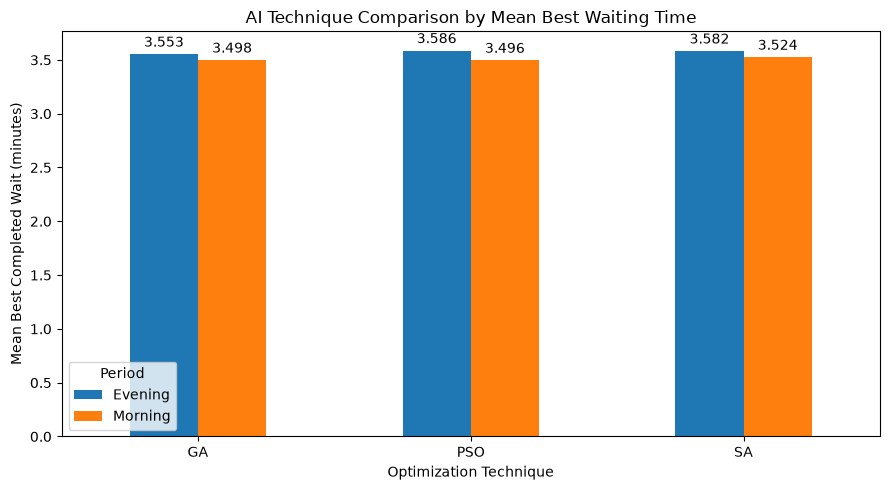

In [41]:
# Compare the three AI techniques using their mean best waiting time.
technique_plot = optimizer_summary.pivot(
    index="Technique",
    columns="Period",
    values="Mean_Best_Wait"
)

ax = technique_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("AI Technique Comparison by Mean Best Waiting Time")
plt.xlabel("Optimization Technique")
plt.ylabel("Mean Best Completed Wait (minutes)")
plt.xticks(rotation=0)
plt.legend(title="Period")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "03_ai_technique_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

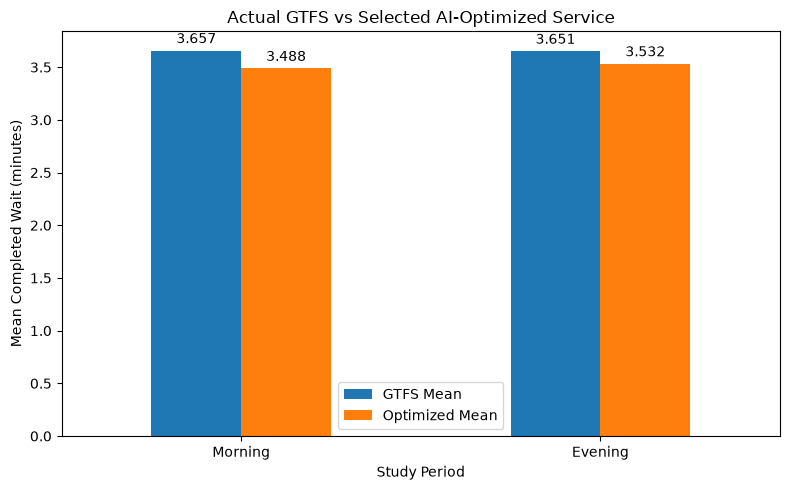

In [42]:
# Compare the actual GTFS mean wait with the selected optimized service plan.
wait_chart = wait_comparison[
    ["Period", "GTFS Mean", "Optimized Mean"]
].set_index("Period")

ax = wait_chart.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Actual GTFS vs Selected AI-Optimized Service")
plt.xlabel("Study Period")
plt.ylabel("Mean Completed Wait (minutes)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "04_gtfs_vs_ai_optimized_wait.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# Save the final AI experiment outputs.
optimizer_runs_export = optimizer_runs_df.copy()
optimizer_runs_export["Best Service Plan"] = (
    optimizer_runs_export["Best Service Plan"].astype(str)
)

selected_service_plans_export = selected_service_plans.copy()
selected_service_plans_export["Service Plan"] = (
    selected_service_plans_export["Service Plan"].astype(str)
)

optimizer_runs_export.to_csv(
    tables_dir / "ai_technique_run_results.csv",
    index=False
)

optimizer_summary.to_csv(
    tables_dir / "ai_technique_summary.csv",
    index=False
)

technique_selection.to_csv(
    tables_dir / "ai_technique_selection.csv",
    index=False
)

selected_service_plans_export.to_csv(
    tables_dir / "selected_ai_service_plans.csv",
    index=False
)

optimized_vs_gtfs.to_csv(
    tables_dir / "optimized_vs_gtfs_paired_comparison.csv",
    index=False
)

print("AI evaluation tables saved.")
print("Selected technique:", selected_technique)

AI evaluation tables saved.
Selected technique: GA


In [44]:
# TECHNICAL DOCUMENTATION USED
# MTA Bus Stop Level Ridership:
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS:
# https://www.mta.info/developers
#
# GTFS Schedule Reference:
# https://gtfs.org/documentation/schedule/reference/
#
# pandas documentation:
# https://pandas.pydata.org/docs/
#
# NumPy documentation:
# https://numpy.org/doc/
#
# SciPy statistics documentation:
# https://docs.scipy.org/doc/scipy/reference/stats.html
#
# Matplotlib documentation:
# https://matplotlib.org/stable/
#
# Python heapq documentation:
# https://docs.python.org/3/library/heapq.html
#
# MAIN METHOD SOURCES USED IN THIS NOTEBOOK
# Law, A. M. (2024). Simulation Modeling and Analysis (6th ed.). McGraw Hill.
#
# Kieu, L. M., & Cai, C. (2018). Stochastic collective model of public
# transport passenger arrival process. IET Intelligent Transport Systems.
# https://doi.org/10.1049/iet-its.2018.0085
#
# Oliveira, J. L. A., Aquino, A. L. L., Pinheiro, R. G. S., & Nogueira, B. (2024).
# Optimizing public transport system using biased random-key genetic algorithm.
# Applied Soft Computing, 158, 111578.
# https://doi.org/10.1016/j.asoc.2024.111578
#
# Ahern, Z., Paz, A., & Corry, P. (2022). Approximate multi-objective optimization
# for integrated bus route design and service frequency setting.
# Transportation Research Part B: Methodological, 155, 1-25.
# https://doi.org/10.1016/j.trb.2021.10.007
#
# Han, Y., Ma, X., & Guo, L. (2022). Regional bus timetable optimization based
# on node importance. CICTP 2022, 522-532.
# https://doi.org/10.1061/9780784484265.049
#
# Gkiotsalitis, K. (2020). Bus scheduling considering trip-varying travel
# times, vehicle availability and capacity. IET Intelligent Transport Systems,
# 14(12), 1594-1605.
# https://doi.org/10.1049/iet-its.2019.0725